# Chunking Pipeline
## CAS NLP — Final Project — University of Bern 2026

Structural chunking of the Jugend und Medien corpus.
Strategy varies by document type:
- **Brochures**: split on chapter headers (`01_`, `02_`...)
- **Extended flyers**: split on age-group section headers (structural heuristic)
- **All other flyers**: single chunk per file
- **Colophon**: removed from all chunks (© marker)

## 1. Environment Setup

In [2]:
import pathlib
import re
import os
import pandas as pd

os.chdir('/Users/Olga 1/Documents/01_AD_ASTRA/0102_LANGUAGES/CAS_NLP_2025/final_project')

brochures = sorted(pathlib.Path("data/used/brochures").glob("*.txt"))
flyers    = sorted(pathlib.Path("data/used/flyers").glob("*.txt"))

extended     = [f for f in flyers if '-ext' in f.name]
standard     = [f for f in flyers if f not in extended]

print(f"Brochures : {len(brochures)}")
print(f"Flyers standard + easy + image-rights : {len(standard)}")
print(f"Flyers extended : {len(extended)}")

Brochures : 15
Flyers standard + easy + image-rights : 36
Flyers extended : 4


## 2. Chunking Functions

Four functions shared across all document types.
`strip_colophon()` removes publisher metadata, searching for the © symbol
in the last 20% of the text only — see section 2.1 for the rationale.

Splitting strategy:
- **Brochures**: content-based split on chapter markers (`01_`, `02_`...)
- **Extended flyers**: language-specific content-based split on section headers,
  determined by corpus inspection (see section 2.1)
- **All other flyers**: single chunk per file

### 2.1 Design Decisions

#### Rejected approach: fixed-size splitting
`RecursiveCharacterTextSplitter` (LangChain) with `chunk_size=1000` and `chunk_overlap=100`
was considered and explicitly rejected. This approach splits text by character count,
ignoring document structure entirely. For the Jugend und Medien corpus, this would break
chapter and age-group boundaries mid-sentence, mixing content from different topics or
age groups in a single chunk. Semantic coherence — essential for RAG retrieval quality —
cannot be guaranteed with fixed-size splitting on a structured corpus.

#### Chosen approach: content-based structural splitting
Chunk boundaries follow the semantic structure of each document type, determined by
corpus inspection rather than assumed in advance.

#### Brochures (DE/FR/IT)
Chapter headers follow a consistent pattern across all three languages: a two-digit
number followed by an underscore (`01_`, `02_`...). This marker is present in all 15
brochure files and provides a reliable, language-agnostic split point. Each chapter
becomes one chunk, preceded by a preamble chunk if the introductory text exceeds 100
words.

#### Extended flyers (RU/SQ/TI/ES)
These documents cover all three age groups (0–7, 6–13, 12–18) in a single file,
with approximately 600–700 words per age-group section. Section headers required
manual inspection of each language before a splitting strategy could be defined:

- **RU**: headers start with an em-dash (U+2014), e.g. `— для родителей детей до 7 лет`,
  confirmed at lines 24, 242, 517. Trailing whitespace required `\s*$` in the pattern.
- **SQ**: headers start with `Shpjegime`, confirmed at lines 21, 206, 470. The second
  and third headers share identical text — position-based filtering (MIN_DISTANCE=200)
  was used instead of text-based deduplication.
- **TI**: headers start with `መግለጽታት`, confirmed at lines 205, 444.
- **ES**: age ranges written as words (*"hasta siete años"*, *"entre seis y trece años"*,
  *"para jóvenes"*) — no numeric or punctuation marker available. Fallback: keyword
  pattern on `para padres` / `para jóvenes`.
- **Future languages**: add a new `elif` branch after corpus inspection. The `else`
  branch provides a trailing-dash fallback (hyphen-minus U+002D or en-dash U+2013)
  as a starting point.

#### Colophon removal
All files end with publisher metadata starting at the © symbol. Initial implementation
searched from the beginning of the text, causing silent failure on brochures: the IT
peer-education brochure contains a colophon page at position 829 of 75,945 characters.
Fix: © is searched only in the last 20% of the text.

#### Standard flyers, Easy Language flyers, Image-rights flyers
Short documents (median 874 words, range 196–6423). Each treated as a single chunk.
Image-rights flyers (196–263 words) are genuinely short — low word count reflects
document design, not an extraction issue.

In [3]:
def strip_colophon(text):
    # Remove publisher metadata: © marker searched in last 20% of text only.
    # Searching from the beginning caused silent failure on brochures:
    # the colophon page appears at position 829 of 75,945 chars in some files,
    # cutting all chapter content before chunking.
    threshold = int(len(text) * 0.8)
    cut = text.find("©", threshold)
    return text[:cut].strip() if cut != -1 else text.strip()


def chunk_brochure(path):
    # Split on chapter headers: lines starting with NN_ (e.g. 01_, 02_)
    lang = path.stem.split("_")[-1]
    text = strip_colophon(path.read_text(encoding="utf-8", errors="ignore"))
    pattern = re.compile(r'^\d{2}_', re.MULTILINE)
    positions = [m.start() for m in pattern.finditer(text)]

    chunks = []
    if positions:
        preamble = text[:positions[0]].strip()
        if len(preamble) > 100:
            chunks.append({"source": path.name, "lang": lang,
                           "chunk_type": "preamble", "chunk_id": 0,
                           "title": "preamble", "text": preamble})
        for i, pos in enumerate(positions):
            end = positions[i+1] if i+1 < len(positions) else len(text)
            chunk_text = text[pos:end].strip()
            title = chunk_text.splitlines()[0]
            chunks.append({"source": path.name, "lang": lang,
                           "chunk_type": "chapter", "chunk_id": i+1,
                           "title": title, "text": chunk_text})
    else:
        chunks.append({"source": path.name, "lang": lang,
                       "chunk_type": "full", "chunk_id": 0,
                       "title": "full", "text": text})
    return chunks


def chunk_extended_flyer(path):
    # Split on age-group section headers.
    # Primary: language-specific header pattern, determined by corpus inspection.
    # Fallback 1 (active): ES keyword pattern (para padres / para jóvenes).
    # Fallback 2: single chunk if fewer than 2 headers found.
    # Note for future languages: add a new elif branch with the appropriate
    # pattern after corpus inspection. The else branch provides a generic
    # trailing-dash fallback as a starting point.
    lang = path.stem.split("_")[-1]
    text = strip_colophon(path.read_text(encoding="utf-8", errors="ignore"))

    if lang == 'ru':
        # RU: headers start with em-dash (U+2014), may have trailing whitespace
        pattern_dash = re.compile(r'^\u2014.{5,80}\s*$', re.MULTILINE)
    elif lang == 'sq':
        # SQ: headers start with "Shpjegime"
        pattern_dash = re.compile(r'^Shpjegime.+$', re.MULTILINE)
    elif lang == 'ti':
        # TI: headers start with "መግለጽታት"
        pattern_dash = re.compile(r'^መግለጽታት.+$', re.MULTILINE)
    else:
        # Fallback for future languages: lines ending with a trailing dash
        # (hyphen-minus U+002D or en-dash U+2013).
        # Activate and refine per language if results are unsatisfactory.
        pattern_dash = re.compile(r'^.+[-\u2013]\s*$', re.MULTILINE)

    matches = list(pattern_dash.finditer(text))

    # Filter by position only — identical header text at different positions
    # represents different sections (e.g. SQ sections 6-13 and 12-18
    # share the same header text in the original document).
    MIN_DISTANCE = 200
    filtered = []
    for m in matches:
        if not filtered or m.start() - filtered[-1].start() > MIN_DISTANCE:
            filtered.append(m)

    if len(filtered) >= 2:
        positions = [m.start() for m in filtered[:3]]
        age_labels = [m.group().strip()[:30] for m in filtered[:3]]
    else:
        # Fallback 1: ES keyword pattern
        lines = text.splitlines()
        positions = []
        age_labels = []
        for line in lines:
            stripped = line.strip()
            if ('para padres' in stripped.lower() or 'para jóvenes' in stripped.lower()) \
                and 20 < len(stripped) < 80:
                pos = text.find(stripped)
                if pos not in positions:
                    positions.append(pos)
                    age_labels.append(stripped[:30])

    if len(positions) >= 2:
        chunks = []
        for i, pos in enumerate(positions):
            end = positions[i+1] if i+1 < len(positions) else len(text)
            chunk_text = text[pos:end].strip()
            chunks.append({"source": path.name, "lang": lang,
                           "chunk_type": "age_section", "chunk_id": i,
                           "title": age_labels[i], "text": chunk_text})
        return chunks
    else:
        return [{"source": path.name, "lang": lang,
                 "chunk_type": "full", "chunk_id": 0,
                 "title": "full", "text": text}]


def chunk_flyer(path):
    # Single chunk per file, colophon removed.
    lang = path.stem.split("_")[-1]
    text = strip_colophon(path.read_text(encoding="utf-8", errors="ignore"))
    return [{"source": path.name, "lang": lang,
             "chunk_type": "full", "chunk_id": 0,
             "title": "full", "text": text}]

## 3. Apply Chunking — Preview and Stats
Chunking applied to all 55 files. Results summarised by chunk type.
Expected: brochures → multiple chapter chunks; extended flyers → 3 age-group
chunks each; all other flyers → 1 chunk each.

In [4]:
all_chunks = []

for f in brochures:
    all_chunks.extend(chunk_brochure(f))

for f in extended:
    all_chunks.extend(chunk_extended_flyer(f))

for f in standard:
    all_chunks.extend(chunk_flyer(f))

df_chunks = pd.DataFrame(all_chunks)
df_chunks["words"] = df_chunks["text"].apply(lambda x: len(x.split()))

print(f"Total chunks: {len(df_chunks)}")
print()
print("=== Chunks by type ===")
print(df_chunks.groupby("chunk_type")[["words"]].agg(["count","mean","min","max"]).round(0))
print()
print("=== Extended flyers — chunks preview ===")
ext_preview = df_chunks[df_chunks["chunk_type"] == "age_section"][["source","title","words"]]
print(ext_preview.to_string(index=False))

Total chunks: 375

=== Chunks by type ===
            words                    
            count    mean   min   max
chunk_type                           
age_section    12  1821.0  1264  2276
chapter       312   680.0     2  4892
full           36   740.0   177  1008
preamble       15   483.0   336   560

=== Extended flyers — chunks preview ===
         source                          title  words
jm-f-ext_es.txt para padres con niños de hasta   1645
jm-f-ext_es.txt para padres con niños de entre   2276
jm-f-ext_es.txt         para padres de jóvenes   2260
jm-f-ext_ru.txt — для родителей детей до 7 лет   1344
jm-f-ext_ru.txt — для родителей детей от 6 до    1825
jm-f-ext_ru.txt     — для родителей подростков   1826
jm-f-ext_sq.txt Shpjegime rekomanduese për për   1632
jm-f-ext_sq.txt Shpjegime lidhur me rekomandim   2240
jm-f-ext_sq.txt Shpjegime lidhur me rekomandim   2200
jm-f-ext_ti.txt መግለጽታት ነቶም ምኽርታት ንምትሓዝ ኤለክትሮናዊ   1264
jm-f-ext_ti.txt መግለጽታት ነቶም ምኽርታት ንምትሓዝ ኤለክትሮናዊ   1689
jm

## 4. Chunk Distribution — Visual Summary

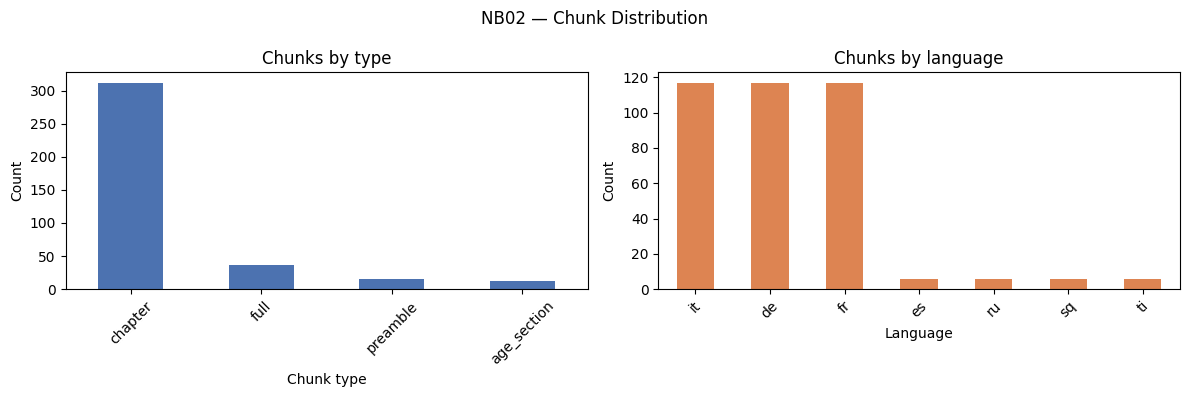

Figure saved.


In [8]:
# Chunk distribution by type and language
import matplotlib.pyplot as plt

df_chunks = pd.DataFrame(all_chunks)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_chunks["chunk_type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Chunks by type")
axes[0].set_xlabel("Chunk type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

df_chunks["lang"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Chunks by language")
axes[1].set_xlabel("Language")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("NB02 — Chunk Distribution")
plt.tight_layout()
plt.savefig("report/figures/nb02_chunk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 5. Save Chunks to Disk

Export chunk dataframe to JSON for use in subsequent notebooks.

In [ ]:
import json

output_path = pathlib.Path("data/chunks/chunks.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

records = df_chunks.to_dict(orient="records")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f"Saved {len(records)} chunks to {output_path}")

Saved 375 chunks to data/chunks/chunks.json
